## Análisis Descriptivo

### Módulos necesarios para la carga y visualización de datos

In [16]:
import polars as pl
from plotnine import aes, geom_bar, geom_histogram, ggplot, labs, theme_bw, theme, element_blank, facet_wrap, element_text, element_rect, scale_fill_manual, scale_x_discrete, after_stat
import pyprojroot

ROOT = pyprojroot.here()

### Carga de Datos

En primer lugar, cargamos la base de datos que se va a utilizar para entrenar modelos.

In [17]:
datos_temporada1 = pl.read_parquet(ROOT / "Datos" / "temporada1.parquet")

### Limpieza de Datos

In [18]:
datos_temporada1.null_count()

pitch_id,release_speed,batter,pitcher,description,stand,p_throws,pitch_type,balls,strikes,pfx_x,pfx_z,plate_x,plate_z,sz_top,sz_bot
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
1381,367,0,0,0,0,0,367,0,0,3033,1060,367,400,367,412


Las variables que presentan valores faltantes son: 
* Identificador único del pitcheo.
* Velocidad del pitcheo.
* Tipo de pitcheo.
* Movimiento horizontal desde la perspectiva del catcher (en pies).
* Movimiento vertical, en pies, desde la perspectiva del catcher.
* Posición horizontal de la pelota cuando cruza el home plate, desde la perspectiva del catcher.
* Posición vertical de la pelota cuando cruza el home plate, desde la perspectiva del catcher.
* Límite superior de la zona de strike del bateador, definido por el operador cuando la pelota está a mitad de camino hacia el home plate.
* Límite inferior de la zona de strike del bateador, definido por el operador cuando la pelota está a mitad de camino hacia el home plate.

Eliminamos los registros con valores faltantes debido a que representan menos del 1 % de los datos. Dado el gran tamaño muestral, la pérdida de información es mínima. Además, realizar una imputación puede incorporar ruido que podría afectar el desempeño de los modelos.

In [19]:
datos_temporada1 = datos_temporada1.drop_nulls()

In [20]:
datos_temporada1.describe()

statistic,pitch_id,release_speed,batter,pitcher,description,stand,p_throws,pitch_type,balls,strikes,pfx_x,pfx_z,plate_x,plate_z,sz_top,sz_bot
str,f64,f64,f64,f64,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",704721.0,704721.0,704721.0,704721.0,"""704721""","""704721""","""704721""","""704721""",704721.0,704721.0,704721.0,704721.0,704721.0,704721.0,704721.0,704721.0
"""null_count""",0.0,0.0,0.0,0.0,"""0""","""0""","""0""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",2.3552e6,88.852346,5787.098877,5793.444164,null,null,null,null,0.883687,0.895208,-0.103943,0.657107,0.044413,2.275039,3.391942,1.573853
"""std""",204933.892232,6.043039,521.421304,525.80555,null,null,null,null,0.968484,0.828375,0.866665,0.747542,0.845991,0.984611,0.164628,0.089671
"""min""",2.000001e6,30.1,5001.0,5003.0,"""ball""","""L""","""L""","""CH""",0.0,0.0,-2.56,-2.13,-6.1,-5.07,2.5,0.77
"""25%""",2.177411e6,84.599998,5334.0,5351.0,null,null,null,null,0.0,0.0,-0.83,0.2,-0.53,1.64,3.3,1.51
"""50%""",2.355343e6,89.900002,5720.0,5728.0,null,null,null,null,1.0,1.0,-0.17,0.76,0.04,2.28,3.41,1.56
"""75%""",2.532745e6,93.699997,6177.0,6176.0,null,null,null,null,2.0,2.0,0.59,1.28,0.62,2.92,3.49,1.62
"""max""",2.709852e6,103.400002,7100.0,7100.0,"""swinging_strike_blocked""","""R""","""R""","""SV""",4.0,2.0,2.84,2.58,9.11,9.39,4.47,2.26


La cantidad de bolas en la cuenta antes del lanzamiento debe ser siempre menor a cuatro porque, cuando el *pitcher* lanza cuatro bolas fuera de la zona de *strike*, el bateador obtiene una base por bolas (camina hacia la siguiente base) y el turno termina inmediatamente. Por este motivo, el único registro con un valor de cuatro en la variable *balls* fue considerado inconsistente y eliminado del conjunto de datos.

In [21]:
datos_temporada1 = datos_temporada1.filter(
    pl.col("balls") != 4
)

### Análisis Univariado

El objetivo del trabajo es predecir la probabilidad de que un bateador realice un *swing* ante un determinado lanzamiento. A partir de la variable que describe el resultado del lanzamiento, creamos una variable que indica si el bateador hizo *swing*.

In [22]:
datos_temporada1["description"].value_counts()

description,count
str,u32
"""ball""",235122
"""swinging_strike""",75228
"""foul_tip""",6683
"""pitchout""",33
"""foul""",125096
…,…
"""called_strike""",115807
"""hit_into_play""",120821
"""foul_pitchout""",1


En *baseball*, luego de que el *pitcher* realiza un lanzamiento, el bateador puede optar por intentar golpear la pelota o dejar pasar el lanzamiento.

**Situaciones en la que el bateador realiza un *swing***
* *hit into play*: el bateador golpea la pelota y esta entra dentro del territorio válido de juego.
* *foul*: el bateador golpea la pelota, pero esta cae en territorio inválido.
    * *foul tip*: el bateador logra golpear la pelota y el *catcher* la atrapa directamente.
    * *foul pitchout*: ocurre cuando el lanzamiento fue un *pitchout* (estrategia defensiva por parte del *pitcher*) y el bateador realiza un *swing* que provoca que la pelota caiga en territorio inválido.
* *swinging strike*: el bateador intenta golpear la pelota pero falla, recibiendo un *strike*.
    * *swinging strike blocked*: variante de *swinging strike* en la que el *catcher* bloquea la pelota.
* *missed bunt*: el bateador intenta realizar un *bunt* (golpe suave a la pelota para que esta caiga en una distancia corta) pero no logra tocar la pelota, resultando en un *strike*.
* *bunt foul tip*: el bateador intenta hacer un *bunt* y produce un *foul tip*.
* *foul bunt*: el bateador realiza un *bunt* y la pelota cae en territorio inválido.

**Situaciones en las que el bateador no realiza un *swing***
* *pitchout*: como estrategia defensiva, el *pitcher* lanza la pelota fuera de la zona de *strike* y no hay intento de bateo por parte del bateador.
* *ball*: lanzamiento fuera de la zona de *strike* que el bateador deja pasar.
* *called strike*: lanzamiento dentro de la zona de *strike* que el bateador no intenta golpear, resultando en un *strike*.
* *hit by pitch*: la pelota golpea al bateador.
* *blocked ball*: la pelota rebota en el suelo, sin que el bateador intente batear.

In [23]:
datos_temporada1 = datos_temporada1.with_columns(
    pl.when(pl.col("description").is_in(["hit_into_play", 
                                        "foul",
                                        "foul_tip",
                                        "foul_pitchout",
                                        "swinging_strike",
                                        "swinging_strike_blocked",
                                        "missed_bunt",
                                        "bunt_foul_tip",
                                        "foul_bunt"]))
    .then(pl.lit(1))
    .otherwise(pl.lit(0))
    .alias("Swing")
)

In [24]:
(
    datos_temporada1["Swing"]
    .value_counts()
    .with_columns(
        (pl.col("count") / pl.col("count").sum()).alias("proporción")
    )
)

Swing,count,proporción
i32,u32,f64
1,334472,0.474617
0,370248,0.525383


El 52 % de los lanzamientos no generan un *swing* por parte del bateador, mientras que el 47 % restante sí lo hacen. La diferencia entre ambas proporciones es pequeña, por lo que la variable respuesta presenta una distribución equilibrada.

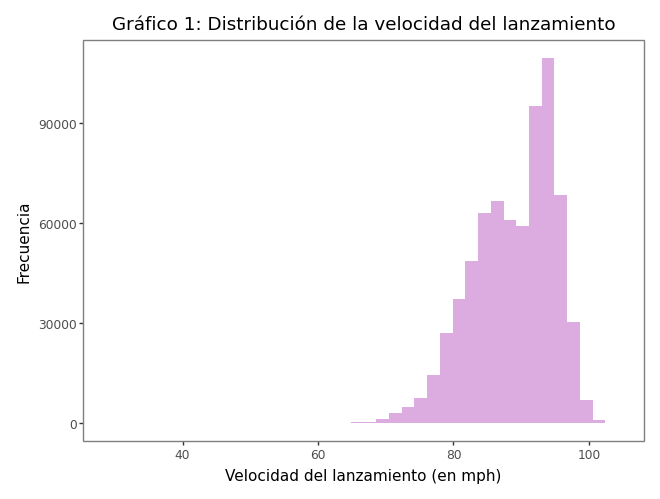

In [25]:
(
    ggplot(datos_temporada1)
    + geom_histogram(aes(x = "release_speed"),
                        bins = 40, 
                        fill = "#DCABDF")
    + 
    labs(
        x = "Velocidad del lanzamiento (en mph)",
        y = "Frecuencia",
        title = "Gráfico 1: Distribución de la velocidad del lanzamiento"
    ) + 
    theme_bw() +
    theme(    
        panel_grid_minor = element_blank(),
        panel_grid_major = element_blank(),
        panel_background = element_blank()
    )
    
)

In [204]:
q1 = datos_temporada1["release_speed"].quantile(0.25)
q3 = datos_temporada1["release_speed"].quantile(0.75)

iqr = q3 - q1

lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

outliers = datos_temporada1.filter(
    (pl.col("release_speed") < lim_inf) |
    (pl.col("release_speed") > lim_sup)
)

La velocidad del lanzamiento tiene una distribución asimétrica, centrada en 88.85 mph. Además, la mayoría de las velocidades se encuentran entre 70.85 y 106.85 mph. Se observan valores atípicos en velocidades bajas, aunque estos representan menos del 1 % de los datos.

In [26]:
(
    datos_temporada1["stand"]
    .value_counts()
    .with_columns(
        (pl.col("count") / pl.col("count").sum()).alias("proporción")
    )
)

stand,count,proporción
str,u32,f64
"""L""",287395,0.407814
"""R""",417325,0.592186


Aproximadamente el 60 % de los bateadores se posicionan en el lado derecho del plato, mientras que el 40,8 % restante se posicionan en el lado izquierdo.

In [27]:
(
    datos_temporada1["p_throws"]
    .value_counts()
    .with_columns(
        (pl.col("count") / pl.col("count").sum()).alias("proporción")
    )
)

p_throws,count,proporción
str,u32,f64
"""R""",495383,0.70295
"""L""",209337,0.29705


El 70 % de los *pitchers* lanzan la bola con la mano derecha. Esto muestra un claro predominio de lanzadores derechos en el conjunto de datos.

In [28]:
datos_temporada1["pitch_type"].value_counts()

pitch_type,count
str,u32
"""CS""",153
"""CU""",53349
"""SC""",1
"""KC""",15195
"""SV""",2629
…,…
"""EP""",127
"""ST""",9254
"""SI""",108062


Según StatCast, los tipos de lanzamiento se puede clasificar en 4 grupos:
* *Fastball*: lanzamiento más común en *baseball* caracterizado por su alta velocidad y fuerza que tiene una trayectoria relativamente pareja. Dentro de esta categoría se encuentran los lanzamientos: FF (*fastball*), SI (*sinker*) y FC (*cutter*).

* *Off-spreed*: lanzamiento significativamente más lento que un *fastball*. La finalidad de este lanzamiento es, generalmente, alterar el tiempo del bateador para disminuir sus chances de golpear la pelota o de hacerlo de manera sólida. Dentro de esta categoría se encuentran los lanzamientos: CH (*change-up*), FS (*slit finger*), FO (*forkball*) y SC (*screwball*).

* *Breaking*: cualquier lanzamiento que no viaja de manera recta. Dentro de esta categoría se encuentran los lanzamientos: CU (*curveball*), KC (*knuckle curve*), CS (*slow curve*), SL (*slinder*), ST (*sweeper*), SV (*slurve*) y KN (*knuckleball*).

* Otros tipos de lanzamientos: *pitchout*, EP (*Eephus*) y FA (otros).

A partir de esta clasificación, creamos una nueva variable para dividir a los tipos de lanzamientos.

In [29]:
datos_temporada1 = datos_temporada1.with_columns(
    pl.when(pl.col("pitch_type").is_in(["FF", "SI", "FC"]))
    .then(pl.lit("Fastball"))

    .when(pl.col("pitch_type").is_in(["CH", "FS", "FO", "SC"]))
    .then(pl.lit("Off-Speed"))

    .when(pl.col("pitch_type").is_in(["CU", "KC", "CS", "SL", "ST", "SV", "KN"]))
    .then(pl.lit("Breaking"))

    .when(pl.col("pitch_type").is_in(["PO", "FA", "EP"]))
    .then(pl.lit("Other"))
    
    .alias("Lanzamiento")
)

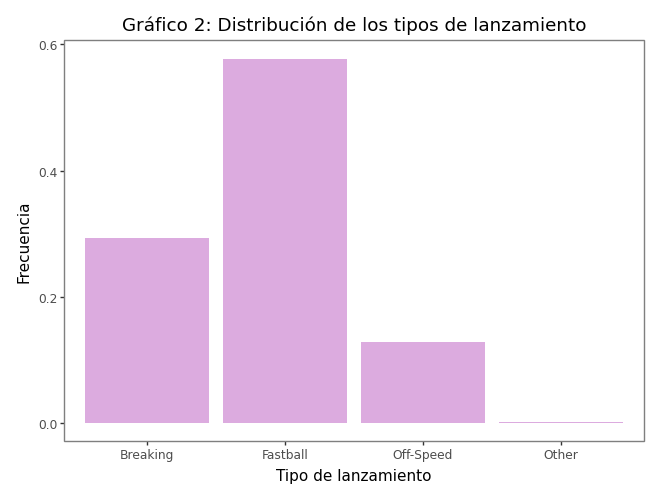

In [30]:
(
    ggplot(datos_temporada1) +
    aes(x = "Lanzamiento") +
    geom_bar(
        aes(y = after_stat("count / sum(count)")),
        fill = "#DCABDF"
    ) +
    labs(
        title="Gráfico 2: Distribución de los tipos de lanzamiento",
        x="Tipo de lanzamiento",
        y="Frecuencia"
    ) + 
    theme_bw() +
    theme(    
        panel_grid_minor = element_blank(),
        panel_grid_major = element_blank(),
        panel_background = element_blank()
    )
)

El tipo de lanzamiento *fastball* es el más utilizado, con más del 50 % de los lanzamientos observados. Esto podría deberse a que estos lanzamientos, al ser una línea recta, son más sencillos de controlar para los *pitchers*. El segundo lanzamiento más común es *breaking* seguido por los *off-speeds*.

In [31]:
(
    datos_temporada1["balls"]
    .value_counts()
    .with_columns(
        (pl.col("count") / pl.col("count").sum()).alias("proporción")
    )
    .sort("proporción")
)

balls,count,proporción
i64,u32,f64
3,58280,0.0827
2,119437,0.169481
1,209035,0.296621
0,317968,0.451198


Se observa una relación decreciente entre la cantidad de bolas en la cuenta y la frecuencia de los lanzamientos. Casi la mitad de los lanzamientos se producen sin bolas acumuladas, mientras que las cuentas de tres bolas representan menos del 10 % de los lanzamientos.

In [32]:
(
    datos_temporada1["strikes"]
    .value_counts()
    .with_columns(
        (pl.col("count") / pl.col("count").sum()).alias("proporción")
    )
    .sort("proporción")
)

strikes,count,proporción
i64,u32,f64
2,208735,0.296196
1,213400,0.302815
0,282585,0.400989


El 40 % de los lanzamientos se realiza cuando la cuenta no presenta *strikes*, mientras que el 30 % ocurre con un *strike* y el 29 % con dos *strikes*. A diferencia de lo observado para la cantidad de bolas, la distribución de strikes es más equilibrada. Si bien los lanzamientos con cero *strikes* son los más frecuentes, las cuentas con uno y dos *strikes* representan conjuntamente cerca del 60 % de los lanzamientos.

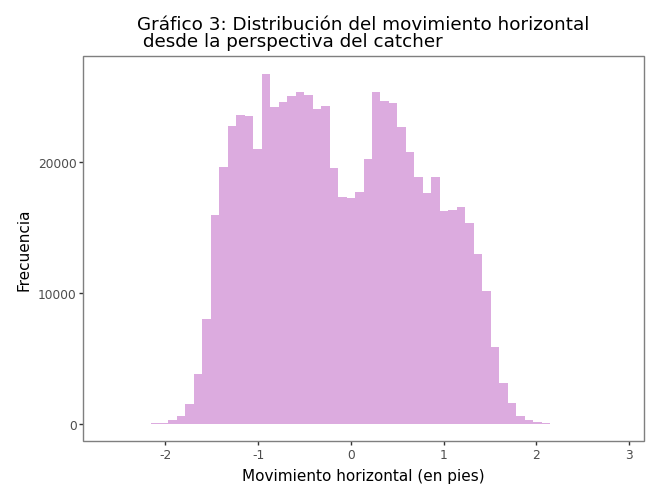

In [33]:
(
    ggplot(datos_temporada1) +
    geom_histogram(
        aes(x = "pfx_x"),
        bins = 60,
        fill = "#DCABDF"
    ) +
    labs(
        x = "Movimiento horizontal (en pies)",
        y = "Frecuencia",
        title = "Gráfico 3: Distribución del movimiento horizontal\n desde la perspectiva del catcher"
    ) +
    theme_bw() +
    theme(
        panel_grid_minor = element_blank(),
        panel_grid_major = element_blank(),
        panel_background = element_blank()
    )
)

La distribución del movimiento horizontal de la pelota, medida desde la perspectiva del catcher, está centrada en -0.1 pies y la mayoría de las observaciones se encuentra entre -2.6 y 2.5 pies. Asimismo, se observan dos modas: una en valores negativos y otra en valores positivos. Esto muestra que hay lanzamientos hacia la izquierda y otros hacia la derecha del *catcher*.

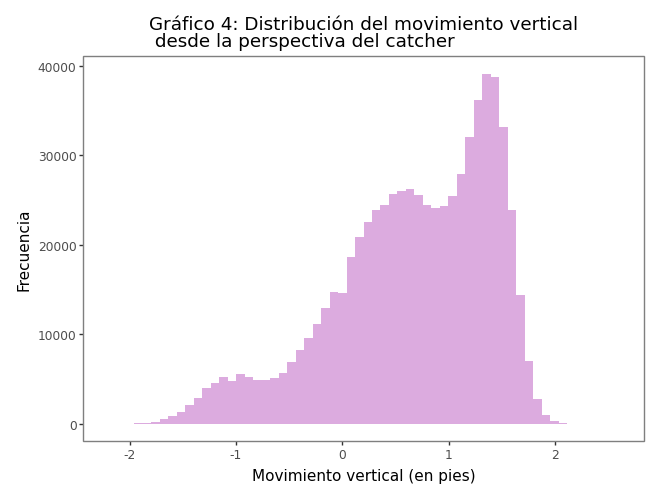

In [34]:
(
    ggplot(datos_temporada1) +
    geom_histogram(aes(x = "pfx_z"),
                        bins = 60, 
                        fill = "#DCABDF") +
    labs(
        x = "Movimiento vertical (en pies)",
        y = "Frecuencia",
        title = "Gráfico 4: Distribución del movimiento vertical\n desde la perspectiva del catcher"
    ) + 
    theme_bw() +
    theme(    
        panel_grid_minor = element_blank(),
        panel_grid_major = element_blank(),
        panel_background = element_blank()
    )
    
)

La distribución del movimiento vertical de la pelota, desde la perpectiva del *catcher*, presenta 3 modas: una en valores negativos, otra alrededor de 0.5 pies y una tercera, más pronunciada, en 1.4 pies. También se observa una alta concentración en valores positivos y una asimetría hacia la izquierda.

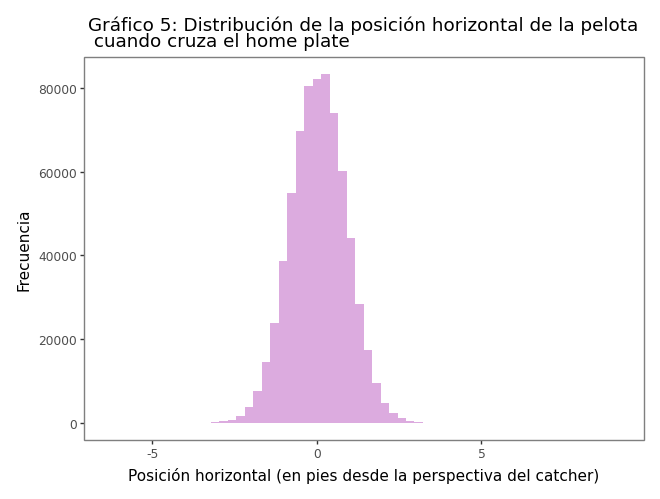

In [36]:
(
    ggplot(datos_temporada1) +
    geom_histogram(aes(x = "plate_x"),
                        bins = 60, 
                        fill = "#DCABDF") + 
    labs(
        x = "Posición horizontal (en pies desde la perspectiva del catcher)",
        y = "Frecuencia",
        title = "Gráfico 5: Distribución de la posición horizontal de la pelota\n cuando cruza el home plate"
    ) + 
    theme_bw() +
    theme(    
        panel_grid_minor = element_blank(),
        panel_grid_major = element_blank(),
        panel_background = element_blank()
    )  
)

In [221]:
q1 = datos_temporada1["plate_x"].quantile(0.25)
q3 = datos_temporada1["plate_x"].quantile(0.75)

iqr = q3 - q1

lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

outliers = datos_temporada1.filter(
    (pl.col("plate_x") < lim_inf) |
    (pl.col("plate_x") > lim_sup)
)

 La distribución posición horizontal de la pelota cuando cruza el *home plate* está centrada en 0.04 pies, lo que indica que, en promedio, los lanzamientos atraviesan una zona cercana al centro del plato. La distribución es aproximadamente simétrica respecto del centro del plato, aunque presenta algunos valores extremos en ambos sentidos.

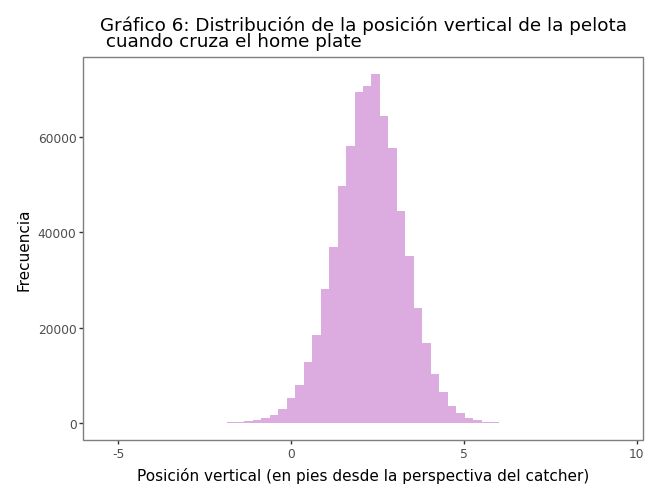

In [37]:
(
    ggplot(datos_temporada1) +
    geom_histogram(aes(x = "plate_z"),
                        bins = 60, 
                        fill = "#DCABDF") + 
    labs(
        x = "Posición vertical (en pies desde la perspectiva del catcher)",
        y = "Frecuencia",
        title = "Gráfico 6: Distribución de la posición vertical de la pelota\n cuando cruza el home plate"
    ) + 
    theme_bw() +
    theme(    
        panel_grid_minor = element_blank(),
        panel_grid_major = element_blank(),
        panel_background = element_blank()
    )
    
)

In [38]:
q1 = datos_temporada1["plate_z"].quantile(0.25)
q3 = datos_temporada1["plate_z"].quantile(0.75)

iqr = q3 - q1

lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

outliers = datos_temporada1.filter(
    (pl.col("plate_z") < lim_inf) |
    (pl.col("plate_z") > lim_sup)
)

La distribución de la posición vertical de la pelota es aproximadamente simétrica y está centrada en 2.28 pies. Además, se observan valores atípicos tanto en el extremo inferior como en el superior de la distribución.

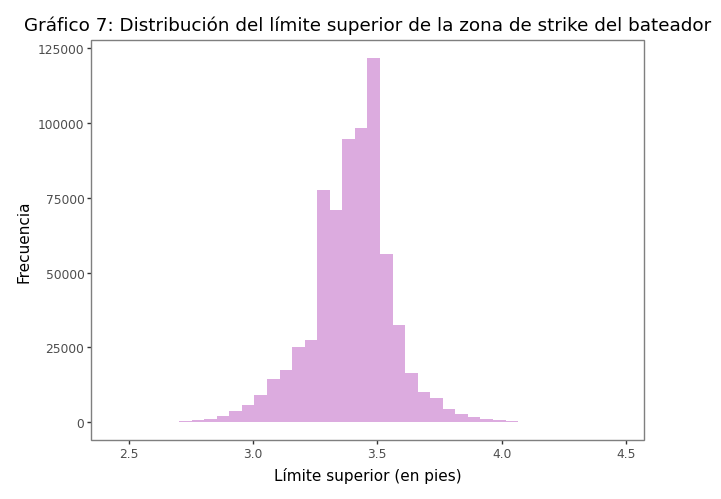

In [39]:
(
    ggplot(datos_temporada1) +
    geom_histogram(aes(x = "sz_top"),
                        bins = 40, 
                        fill = "#DCABDF") + 
    labs(
        x = "Límite superior (en pies)",
        y = "Frecuencia",
        title = "Gráfico 7: Distribución del límite superior de la zona de strike del bateador"
    ) + 
    theme_bw() +
    theme(    
        panel_grid_minor = element_blank(),
        panel_grid_major = element_blank(),
        panel_background = element_blank()
    )
    
)

In [40]:
q1 = datos_temporada1["sz_top"].quantile(0.25)
q3 = datos_temporada1["sz_top"].quantile(0.75)

iqr = q3 - q1

lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

outliers = datos_temporada1.filter(
    (pl.col("sz_top") < lim_inf) |
    (pl.col("sz_top") > lim_sup)
)

Se observa que la distribución del límite superior de la zona de *strike* es aproximadamente simétrica y está centrada en 3.39 pies. La mayoría de los límites superiores de la zona de *strike* están entre 2.91 y 3.87 pies. También se observan valores atípicos en ambos extremos de la distribución.

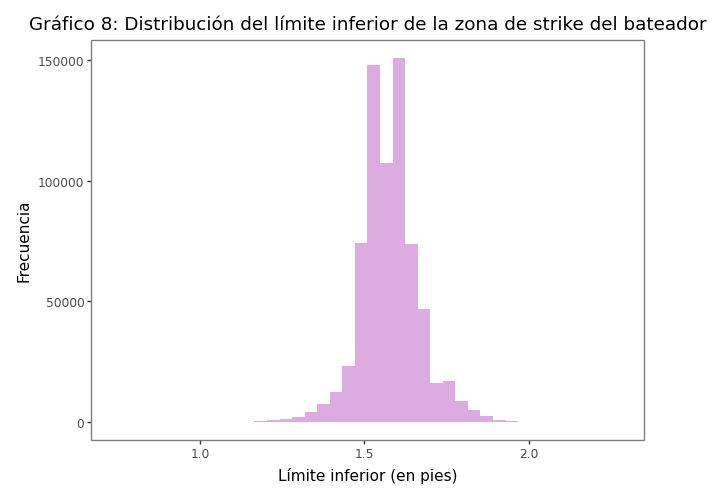

In [41]:
(
    ggplot(datos_temporada1) +
    geom_histogram(aes(x = "sz_bot"),
                        bins = 40, 
                        fill = "#DCABDF") + 
    labs(
        x = "Límite inferior (en pies)",
        y = "Frecuencia",
        title = "Gráfico 8: Distribución del límite inferior de la zona de strike del bateador"
    ) + 
    theme_bw() +
    theme(    
        panel_grid_minor = element_blank(),
        panel_grid_major = element_blank(),
        panel_background = element_blank()
    )
    
)

In [42]:
q1 = datos_temporada1["sz_bot"].quantile(0.25)
q3 = datos_temporada1["sz_bot"].quantile(0.75)

iqr = q3 - q1

lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr

outliers = datos_temporada1.filter(
    (pl.col("sz_bot") < lim_inf) |
    (pl.col("sz_bot") > lim_sup)
)

La distribución del límite inferior de la zona de *strike* es aproximadamente simétrica y está centrada en 1.57 pies. La mayoría de los límites superiores de la zona de *strike* están entre 1.33 y 1.81 pies. Además, se observan valores extremos tanto en el extremo inferior como en el superior de la distribución.

### Análisis Bivariado

Con la finalidad de estudiar la relación entre las variables explicativas, calculamos la matriz de correlación entre ellas.

In [43]:
continuas = [
    "release_speed",
    "pfx_x",
    "pfx_z",
    "plate_x",
    "plate_z",
    "sz_top",
    "sz_bot"
]

matriz_corr = (
    datos_temporada1
    .select(continuas)
    .to_pandas()
    .corr()
)

matriz_corr

,release_speed,pfx_x,pfx_z,plate_x,plate_z,sz_top,sz_bot
release_speed,1.000000,-0.279239,0.727547,-0.042104,0.272504,0.032221,0.029389
pfx_x,-0.279239,1.000000,-0.203775,0.234416,-0.059033,-0.002399,-0.001394
pfx_z,0.727547,-0.203775,1.000000,-0.045404,0.345032,0.033260,0.026590
plate_x,-0.042104,0.234416,-0.045404,1.000000,-0.158949,0.002949,0.006864
plate_z,0.272504,-0.059033,0.345032,-0.158949,1.000000,0.023367,0.003074
sz_top,0.032221,-0.002399,0.033260,0.002949,0.023367,1.000000,0.779206
sz_bot,0.029389,-0.001394,0.026590,0.006864,0.003074,0.779206,1.000000


En general, la correlación lineal entre las variables es baja o moderada. 

Luego, graficamos la distribución de cada variable según si el bateador realizó un *swing* o no, con el objetivo de identificar posibles diferencias entre ambos grupos.

In [44]:
datos_graf = datos_temporada1.with_columns(
    pl.when(pl.col("Swing") == 1)
    .then(pl.lit("Swing"))
    .otherwise(pl.lit("No Swing"))
    .alias("Swing_label")
)

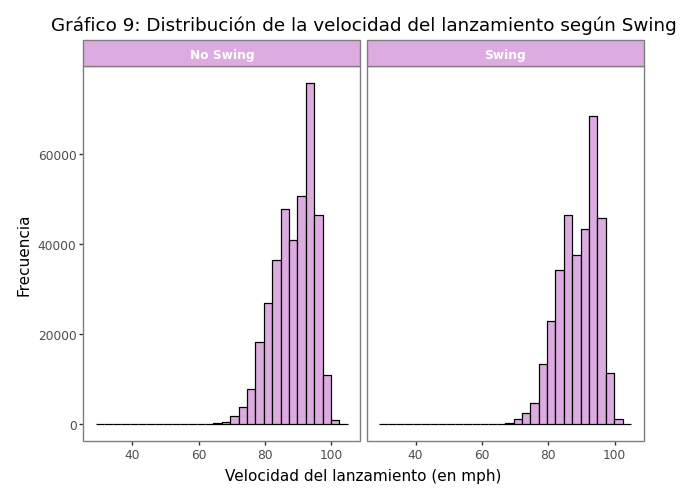

In [45]:
(
    ggplot(datos_graf) +
    aes(x = "release_speed") +
    geom_histogram(
        bins = 30,
        fill = "#DCABDF",
        color = "black"
    ) +
    facet_wrap("~Swing_label") +
    labs(
        x = "Velocidad del lanzamiento (en mph)",
        y = "Frecuencia",
        title = "Gráfico 9: Distribución de la velocidad del lanzamiento según Swing"
    ) +
    theme_bw() + 
    theme(
        panel_grid_minor = element_blank(),
        panel_grid_major = element_blank(),
        panel_background = element_blank(),
        strip_background = element_rect(
            fill = "#DCABDF"
        ),
        strip_text = element_text(
            color = "white",
            weight = "bold"
        )
    )
)

No se obervan diferencias en la distribución de la velocidad del lanzamiento según si el bateador realizó un *swing* o no, por lo que no parece existir una relación entre ambas variables.

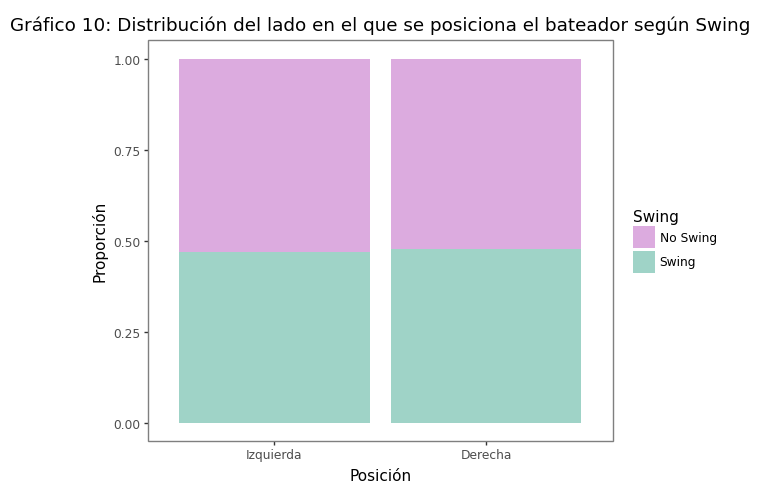

In [47]:
(
    ggplot(datos_graf) +
    aes(
        x = "stand",
        fill = "factor(Swing_label)"
    ) +
    geom_bar(position = "fill") +
    scale_fill_manual(
        values=["#DCABDF", "#9FD3C7"]
    ) +
    scale_x_discrete(
        labels = {
            "L": "Izquierda",
            "R": "Derecha"
        }
    ) +
    labs(
        x = "Posición",
        y = "Proporción",
        fill = "Swing",
        title = "Gráfico 10: Distribución del lado en el que se posiciona el bateador según Swing"
    ) +
    theme_bw() +
    theme(
        panel_grid_minor = element_blank(),
        panel_grid_major = element_blank(),
        panel_background = element_blank()
    )
)

La proporción de *swing* es muy similar entre los bateadores que se posicionan a la izquierda o a la derecha del plato; no se observa una relación evidente entre ambas variables.

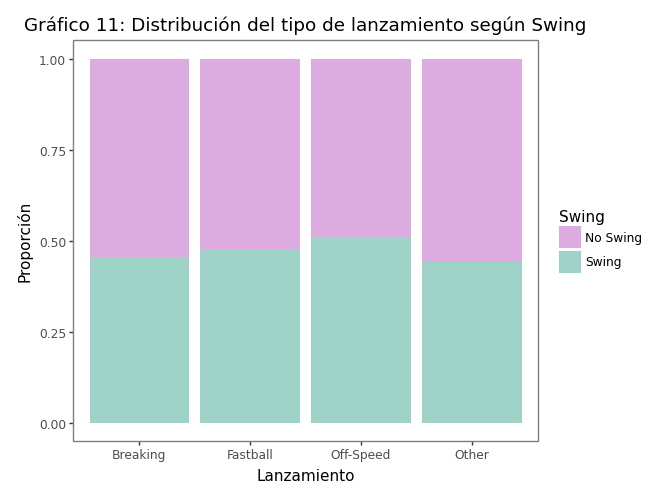

In [48]:
(
    ggplot(datos_graf) +
    aes(
        x = "Lanzamiento",
        fill = "factor(Swing_label)"
    ) +
    geom_bar(position = "fill") +
    labs(
        y = "Proporción",
        fill = "Swing",
        title = "Gráfico 11: Distribución del tipo de lanzamiento según Swing"
    ) +
    scale_fill_manual(
        values=["#DCABDF", "#9FD3C7"]
    ) +
    theme_bw() +
    theme(
        panel_grid_minor = element_blank(),
        panel_grid_major = element_blank(),
        panel_background = element_blank()
    )
)

Los distintos tipos de lanzamiento presentan proporciones de *swing* muy similares entre sí, todas ellas cercanas, aunque levemente inferiores, al 50 %. Esto sugiere que el tipo de lanzamiento no parece estar fuertemente asociado con la decisión de realizar un *swing*.

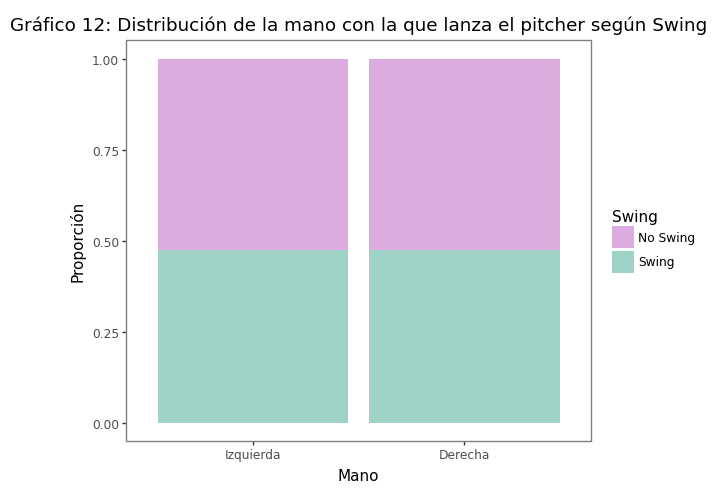

In [49]:
(
    ggplot(datos_graf) +
    aes(
        x = "p_throws",
        fill = "factor(Swing_label)"
    ) +
    geom_bar(position = "fill") +
    scale_fill_manual(
        values = ["#DCABDF", "#9FD3C7"]
    ) +
    scale_x_discrete(
        labels = {
            "L": "Izquierda",
            "R": "Derecha"
        }
    ) +
    labs(
        x = "Mano",
        y = "Proporción",
        fill = "Swing",
        title = "Gráfico 12: Distribución de la mano con la que lanza el pitcher según Swing"
    ) +
    theme_bw() +
    theme(
        panel_grid_minor = element_blank(),
        panel_grid_major = element_blank(),
        panel_background = element_blank()
    )
)

No se observa una relación entre la mano con la que el *pitcher* lanza la pelota y la decisión del bateador de hacer un *swing* ya que, para ambas manos, la proporción es aproximadamente 0.50.

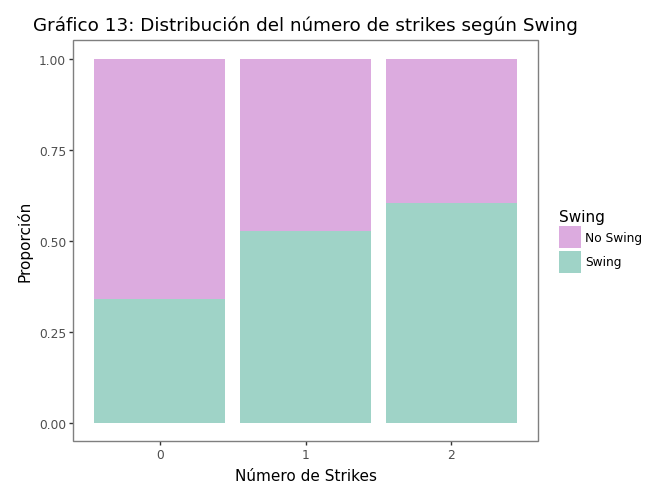

In [50]:
(
    ggplot(datos_graf) +
    aes(
        x = "strikes",
        fill = "factor(Swing_label)"
    )
    + geom_bar(position = "fill") +
    scale_fill_manual(
        values = ["#DCABDF", "#9FD3C7"]
    ) +
    labs(
        x = "Número de Strikes",
        y = "Proporción",
        fill = "Swing",
        title = "Gráfico 13: Distribución del número de strikes según Swing"
    ) +
    theme_bw() +
    theme(
        panel_grid_minor = element_blank(),
        panel_grid_major = element_blank(),
        panel_background = element_blank()
    )
)

Cuando la cuenta no registra *strikes*, en más del 50 % de los lanzamientos los bateadores no realizan un *swing*. Con un *strike* en la cuenta, la proporción de *swing* y no *swing* es aproximadamente la misma. En cambio, cuando la cuenta alcanza los dos *strikes*, más del 50 % de los lanzamientos generan un *swing* por parte del bateador. Es decir, a medida que aumenta la cantidad de *strikes* en la cuenta, también aumenta la proporción de *swings*. Este comportamiento es esperable, ya que con dos *strikes* el bateador se encuentra a un lanzamiento de ser eliminado. 

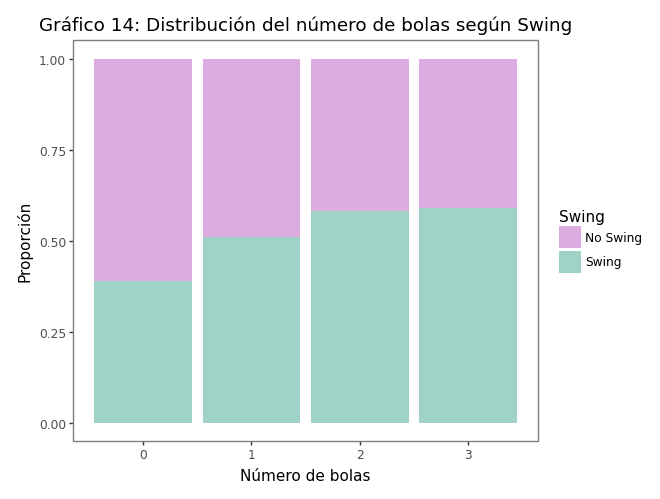

In [52]:
(
    ggplot(datos_graf) +
    aes(
        x = "balls",
        fill = "factor(Swing_label)"
    )
    + geom_bar(position = "fill") +
    scale_fill_manual(
        values = ["#DCABDF", "#9FD3C7"]
    ) +
    labs(
        x = "Número de bolas",
        y = "Proporción",
        fill = "Swing",
        title = "Gráfico 14: Distribución del número de bolas según Swing"
    ) +
    theme_bw() +
    theme(
        panel_grid_minor = element_blank(),
        panel_grid_major = element_blank(),
        panel_background = element_blank()
    )
)

A medida que aumenta la cantidad de bolas en la cuenta, también aumenta la proporción de *swings*. Cuando no hay bolas, la proporción de lanzamientos en los que el bateador no realiza un *swing* supera el 50 %. Con una bola en la cuenta, las proporciones de *swing* y no *swing* son aproximadamente iguales. En cambio, cuando la cuenta acumula dos o tres bolas, la proporción de *swing* supera el 50 %. Este comportamiento podría deberse a que, a medida que aumenta la cantidad de bolas, el bateador se acerca a obtener una base por bolas. Es por esto que los *pitchers* se ven obligados a lanzar más cerca de la zona de *strike*, aumentando la probabilidad de que el bateador decida realizar un *swing*.

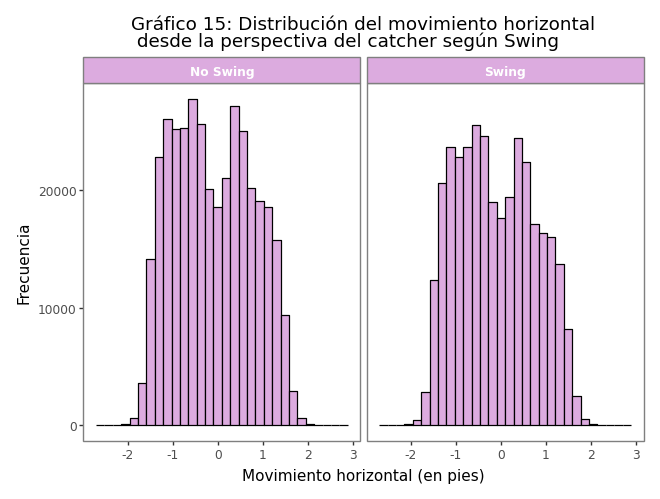

In [53]:
(
    ggplot(datos_graf) +
    aes(x = "pfx_x") +
    geom_histogram(
        bins = 30,
        fill = "#DCABDF",
        color = "black"
    ) +
    facet_wrap("~Swing_label") +
    labs(
        x = "Movimiento horizontal (en pies)",
        y = "Frecuencia",
        title = "Gráfico 15: Distribución del movimiento horizontal\n desde la perspectiva del catcher según Swing"
    ) +
    theme_bw() + 
    theme(
        panel_grid_minor = element_blank(),
        panel_grid_major = element_blank(),
        panel_background = element_blank(),
        strip_background = element_rect(
            fill = "#DCABDF"
        ),
        strip_text = element_text(
            color = "white",
            weight = "bold"
        )
    )
)

No se obervan diferencias en la distribución del movimiento horizontal del lanzamiento según si el bateador realizó un *swing* o no. Es decir, parece que no existe una relación entre ambas variables.

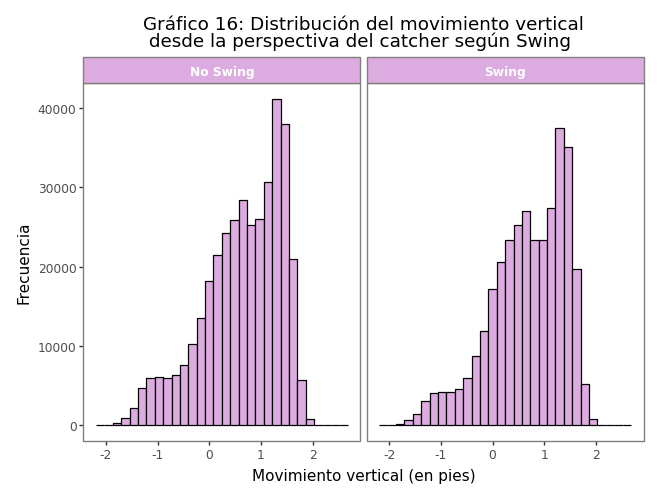

In [54]:
(
    ggplot(datos_graf) +
    aes(x = "pfx_z") +
    geom_histogram(
        bins = 30,
        fill = "#DCABDF",
        color = "black"
    ) +
    facet_wrap("~Swing_label") +
    labs(
        x = "Movimiento vertical (en pies)",
        y = "Frecuencia",
        title = "Gráfico 16: Distribución del movimiento vertical\n desde la perspectiva del catcher según Swing"
    )
    + theme_bw() + 
    theme(
        panel_grid_minor = element_blank(),
        panel_grid_major = element_blank(),
        panel_background = element_blank(),
        strip_background = element_rect(
            fill = "#DCABDF"
        ),
        strip_text = element_text(
            color = "white",
            weight = "bold"
        )
    )
)

No se obervan diferencias en la distribución del movimiento vertical del lanzamiento según si el bateador realizó un *swing* o no, por lo que no parece existir una relación entre ambas variables.

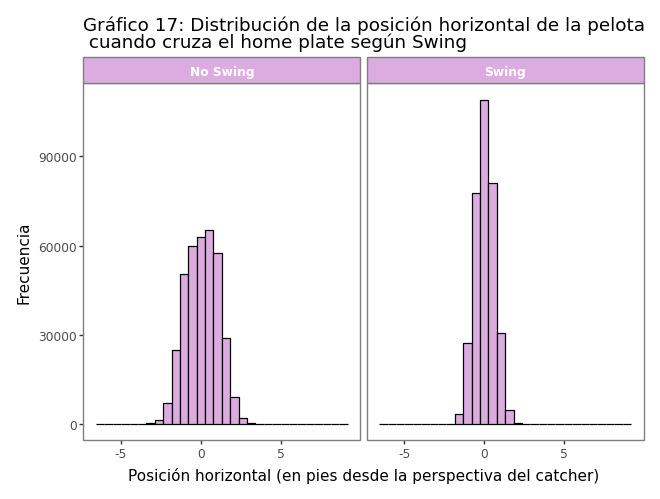

In [180]:
(
    ggplot(datos_graf) +
    aes(x = "plate_x") +
    geom_histogram(
        bins = 30,
        fill = "#DCABDF",
        color = "black"
    ) +
    facet_wrap("~Swing_label") + 
    labs(
        x = "Posición horizontal (en pies desde la perspectiva del catcher)",
        y = "Frecuencia",
        title = "Gráfico 17: Distribución de la posición horizontal de la pelota\n cuando cruza el home plate según Swing"
    ) +
    theme_bw() + 
    theme(
        panel_grid_minor = element_blank(),
        panel_grid_major = element_blank(),
        panel_background = element_blank(),
        strip_background = element_rect(
            fill = "#DCABDF"
        ),
        strip_text = element_text(
            color = "white",
            weight = "bold"
        )
    )
)

La distribución de los lanzamientos en los que el bateador realizó un *swing* está más concentrada alrededor del centro del plato (0 pies), mientras que la distribución de los lanzamientos en los que no realizó un *swing* es más dispersa. Parece que los bateadores tienden a realizar *swing* con mayor frecuencia cuando la pelota atraviesa una zona cercana al centro del plato, mientras que los lanzamientos más alejados de dicha zona tienen una mayor probabilidad de no generar un *swing*.

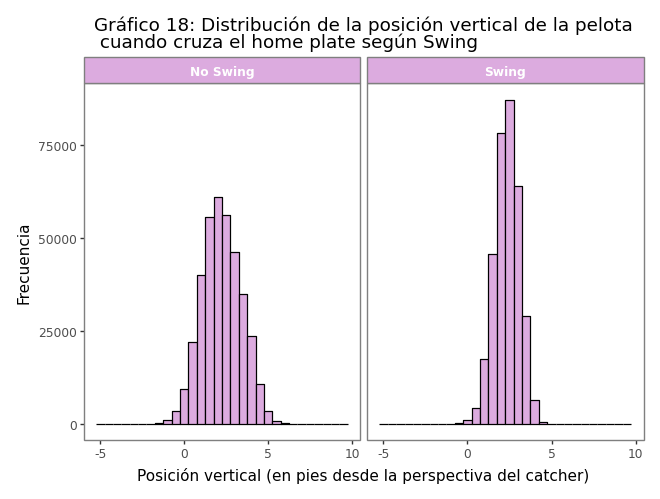

In [55]:
(
    ggplot(datos_graf) + 
    aes(x = "plate_z") +
    geom_histogram(
        bins = 30,
        fill = "#DCABDF",
        color = "black"
    ) +
    facet_wrap("~Swing_label") +
    labs(
        x = "Posición vertical (en pies desde la perspectiva del catcher)",
        y = "Frecuencia",
        title = "Gráfico 18: Distribución de la posición vertical de la pelota\n cuando cruza el home plate según Swing"
    ) +
    theme_bw() + 
    theme(
        panel_grid_minor = element_blank(),
        panel_grid_major = element_blank(),
        panel_background = element_blank(),
        strip_background = element_rect(
            fill = "#DCABDF"
        ),
        strip_text = element_text(
            color = "white",
            weight = "bold"
        )
    )
)

Los lanzamientos que generan un *swing* presentan una mayor concentración en alturas intermedias (cercana a la zona de *strike*). Mientras que aquellos en los que el bateador no realiza un *swing* muestran una mayor dispersión. Por lo tanto, los lanzamientos que pasan a alturas muy bajas o muy altas parecen tener una mayor probabilidad de no generar un *swing*.

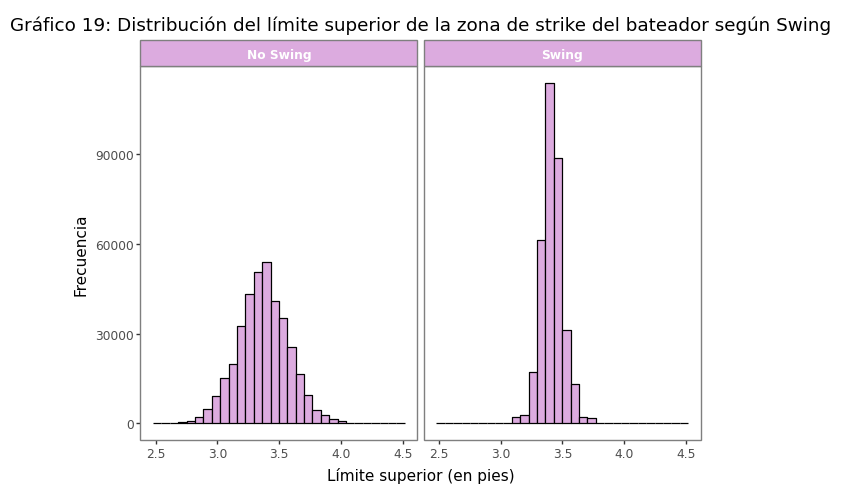

In [56]:
(
    ggplot(datos_graf) +
    aes(x = "sz_top") +
    geom_histogram(
        bins = 30,
        fill = "#DCABDF",
        color = "black"
    ) +
    facet_wrap("~Swing_label") +
    labs(
        x = "Límite superior (en pies)",
        y = "Frecuencia",
        title = "Gráfico 19: Distribución del límite superior de la zona de strike del bateador según Swing"
    ) +
    theme_bw() + 
    theme(
        panel_grid_minor = element_blank(),
        panel_grid_major = element_blank(),
        panel_background = element_blank(),
        strip_background = element_rect(
            fill = "#DCABDF"
        ),
        strip_text = element_text(
            color = "white",
            weight = "bold"
        )
    )
)

Los lanzamientos que generan un *swing* presentan una mayor concentración del límite superior de la zona de *strike* alrededor de 3.4 pies, mientras que los lanzamientos en los que el bateador no realiza un *swing* muestran una mayor dispersión. Esto sugiere que los *swings* ocurren con mayor frecuencia cuando el límite superior de la zona de *strike* toma valores cercanos a su valor promedio.

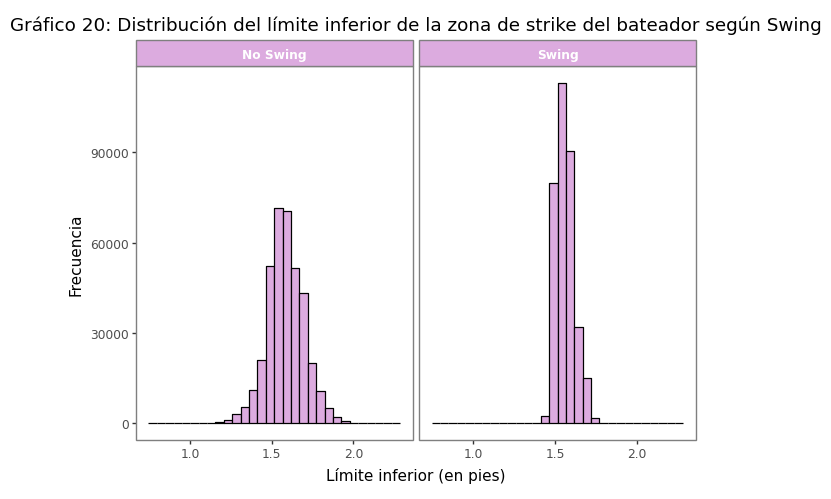

In [57]:
(
    ggplot(datos_graf) +
    aes(x = "sz_bot") +
    geom_histogram(
        bins = 30,
        fill = "#DCABDF",
        color = "black"
    ) +
    facet_wrap("~Swing_label") +
    labs(
        x = "Límite inferior (en pies)",
        y = "Frecuencia",
        title = "Gráfico 20: Distribución del límite inferior de la zona de strike del bateador según Swing"
    ) +
    theme_bw() + 
    theme(
        panel_grid_minor = element_blank(),
        panel_grid_major = element_blank(),
        panel_background = element_blank(),
        strip_background = element_rect(
            fill = "#DCABDF"
        ),
        strip_text = element_text(
            color = "white",
            weight = "bold"
        )
    )
)

La distribución de los lanzamientos en los que el bateador realizó un *swing* está más concentrada alrededor de la media del límite inferior de la zona de *strike* (1.57 pies), mientras que la correspondiente a los lanzamientos en los que no realizó un *swing* presenta una mayor dispersión.

Finalmente, guardamos los datos depurados.

In [98]:
datos_temporada1.write_parquet(ROOT / "Datos/datos_temporada1.parquet")